#  06. Real VLM Validation Experiment

**Theme**: Calibrate the Load Balancer's **Latency Expectations** against **Reality**.

## The Problem
The Load Balancer uses `base_latency_ms` (config) to estimate completion time. If this estimate is wrong, SLA diversion will be inaccurate.

## The Experiment
1. Pick 5 real prompts from DB.
2. Route them to a model.
3. **Actually Call the VLM API** (if available).
4. Compare `LB Predicted Latency` vs `Actual Wall-Clock Latency`.

> **Note**: This notebook requires the `inference_engine` module and valid API keys (via `.env`). If not available, it runs in **Mock Mode**.

In [1]:
import sys
from pathlib import Path
# Path setup
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
ARTEMIS_DIR = ROOT_DIR / 'artemis_final'
CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ARTEMIS_DIR))

In [2]:
import time 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Imports
from sqlalchemy import create_engine, text
from artemis_final.load_balancer.public_api import (
    load_capacity_config,
    StatsRegistry,
    ArtemisLoadBalancer,
    RouterOutput,
    SchedulingContext,
    ModelCapacityConfig
)
from artemis_final.ares.configs.db_config import DB_URL, TABLES

DB_AVAILABLE = True
VLM_CLIENT_AVAILABLE = True # Default to Mock for safety

# Load Capacity Config (Updated)
from artemis_final.load_balancer.public_api import load_capacity_config

try:
    # Try to load the config that matches the router's models
    capacity_config = load_capacity_config('multitask_router_v1')
    print(" Loaded capacity config for multitask_router_v1")
except Exception as e:
    print(f"️ Failed to load multitask_router_v1 config: {e}")
    print("   Falling back to default capacity config (gemma, qwen, deepseek)")
    # Fallback to a known good config if the specific one isn't found
    capacity_config = {
        'gemma_3_27b': {'max_capacity': 100, 'cost_per_token': 0.0001},
        'qwen_1_8b': {'max_capacity': 100, 'cost_per_token': 0.00005},
        'deepseek_6_7b': {'max_capacity': 100, 'cost_per_token': 0.00008},
    }
    print("   Using hardcoded fallback capacity config.")

print("Capacity Config:")                         
for model, config in capacity_config.items():
    print(f"  {model}: {config}")

# Placeholder for VLM inference, if applicable
call_vlm = False # Set to True if VLM inference is desired
print(f"\nVLM INFERENCE: Skipped (call_vlm={call_vlm})\n")


 Loaded capacity config for multitask_router_v1
Capacity Config:
  gemma_3_27b: ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, min_replicas=1, max_replicas=2, sla_ms=4000, max_qps_per_replica=0.5, cost_per_request_usd=0.0005, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen3_vl_8b_thinking: ModelCapacityConfig(model_name='qwen3_vl_8b_thinking', base_latency_ms=1200, min_replicas=1, max_replicas=3, sla_ms=3000, max_qps_per_replica=0.8, cost_per_request_usd=0.003, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl_7b: ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, min_replicas=1, max_replicas=4, sla_ms=2500, max_qps_per_replica=1.2, cost_per_request_usd=0.0004, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl


## How to Enable Real Inference
1. Open `artemis_final/ares/configs/models.yaml` and add your real API keys/endpoints.
2. Set `VLM_CLIENT_AVAILABLE = True` in the cell above.
3. Run the cells below.


In [3]:

# === Real VLM Client Setup ===
from artemis_final.inference_engine import WhichVLMClient
from pathlib import Path

class SimpleVLMClient:
    def __init__(self, config_rel_path="ares/configs/models.yaml"):
        # Resolve path relative to artemis_final root
        # We are in examples/load_balancer (2 levels down)
        root_dir = Path.cwd().parent.parent
        self.config_path = root_dir / "artemis_final" / config_rel_path
        
        self.client = None
        if self.config_path.exists():
            print(f"Loading VLM Client from: {self.config_path}")
            try:
                self.client = WhichVLMClient.from_yaml(self.config_path)
            except Exception as e:
                print(f"Failed to load VLM Client: {e}")
        else:
            print(f"Warning: Config not found at {self.config_path}. Real inference will not work.")

    def chat(self, prompt, model, image=None):
        if not self.client:
            # If client failed to load, simulate a failure so the loop catches it
            raise RuntimeError("Client not initialized (check models.yaml path and keys).")
            
        # Construct message
        messages = [{"role": "user", "content": prompt}]
        # Note: 'image' arg currently ignored as it passed as None in this notebook
        
        # Call runner
        print(f"   [Sending request to {model} via {self.client.runner.clients[model][0].base_url} ...]")
        resp = self.client.runner.chat(model_name=model, messages=messages)
        
        if not resp['ok']:
            raise RuntimeError(f"API Error: {resp.get('error_message')}")
            
        return resp


In [4]:

# Initialize Client if requested
if VLM_CLIENT_AVAILABLE:
    print("Initializing Real VLM Client...")
    client = SimpleVLMClient()
else:
    print("VLM_CLIENT_AVAILABLE = False. Using Mock Mode.")
    client = None


Initializing Real VLM Client...
Loading VLM Client from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/ares/configs/models.yaml


In [5]:
# Setup LB
model_configs = load_capacity_config()
lb = ArtemisLoadBalancer(
    model_configs=model_configs,
    stats_registry=StatsRegistry(),
    latency_sla_ms={'default': 5000},
    scheduling_mode='capacity_aware',
    simulation_only=False, # We want state to update
)

print(" Load Balancer Initialized")

 Load Balancer Initialized


In [6]:
# Load 5 Real Prompts
prompts = []

if DB_AVAILABLE:
    try:
        engine = create_engine(DB_URL)
        with engine.connect() as conn:
            result = conn.execute(text(f"""
                SELECT s.sample_id, s.prompt_text, i.image_path
                FROM {TABLES['samples']} s
                JOIN {TABLES['images']} i ON s.image_id = i.image_id
                WHERE s.prompt_text IS NOT NULL
                AND s.image_id IS NOT NULL
                AND i.image_path IS NOT NULL
                ORDER BY RANDOM() LIMIT 5
            """))

            prompts = [{'sample_id': r[0], 'prompt': r[1], 'image_path': r[2]} for r in result.fetchall()]

    except Exception as e: print(e)

if not prompts:
    prompts = [{'sample_id': f'syn_{i}', 'prompt': f'Test prompt {i}'} for i in range(5)]

print(f" Loaded {len(prompts)} prompts")

 Loaded 5 prompts


---
## Run Validation Loop

We will manually compare `dec.est_latency_ms` (Predicted) vs `e - s` (Actual).

In [7]:
results = []

for p in prompts:
    print(f"\nProcessing {p['sample_id']}...")
    
    # 1. Schedule
    ro = RouterOutput(
        sample_id=p['sample_id'], task_type='general',
        router_probs={'qwen2_5_vl_7b': 0.9}, preferred_model='qwen2_5_vl_7b',
        max_prob=0.9
    )
    ctx = SchedulingContext(arrival_ts_ms=time.time()*1000, load_profile='normal')
    decision = lb.schedule(ro, ctx)
    
    model = decision.chosen_model
    pred_lat = decision.total_latency_ms
    
    # 2. Execute (Real or Mock)
    start_t = time.time()
    actual_lat = 0
    
    if VLM_CLIENT_AVAILABLE:
        try:
            resp = client.chat(prompt=p['prompt'], model=model, image=p.get('image_path')) 
            actual_lat = (time.time() - start_t) * 1000
            status = "Real Call"
        except Exception as e:
            print(f"   Client Call Failed (Expected if NO API KEY): {e}")
            # Fallback to mock sleep
            time.sleep(np.random.uniform(0.5, 1.5)) 
            actual_lat = (time.time() - start_t) * 1000
            status = "Mocked (Client Error)"
    else:
        time.sleep(np.random.uniform(0.5, 1.5))
        actual_lat = (time.time() - start_t) * 1000
        status = "Mocked"
        
    print(f"   Model: {model}")
    print(f"   Predicted: {pred_lat:.0f}ms | Actual: {actual_lat:.0f}ms ({status})")
    
    results.append({
        'sample_id': p['sample_id'],
        'model': model,
        'pred_latency_ms': pred_lat,
        'actual_latency_ms': actual_lat,
        'error_ms': actual_lat - pred_lat
    })

Missing 'avg_accuracy' stats for task='general', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_latency_ms' stats for task='general', model='qwen2_5_vl_7b'. Using default value.
Missing 'cost_per_request_usd' stats for task='general', model='qwen2_5_vl_7b'. Using default value.



Processing syn_0...
   [Sending request to qwen2_5_vl_7b via https://api.openai.com/v1/ ...]
   Client Call Failed (Expected if NO API KEY): API Error: Failed after 3 retries: dict() got multiple values for keyword argument 'temperature'
   Model: qwen2_5_vl_7b
   Predicted: 1000ms | Actual: 2748ms (Mocked (Client Error))

Processing syn_1...
   [Sending request to qwen2_5_vl_7b via https://api.openai.com/v1/ ...]
   Client Call Failed (Expected if NO API KEY): API Error: Failed after 3 retries: dict() got multiple values for keyword argument 'temperature'
   Model: qwen2_5_vl_7b
   Predicted: 1000ms | Actual: 2212ms (Mocked (Client Error))

Processing syn_2...
   [Sending request to qwen2_5_vl_7b via https://api.openai.com/v1/ ...]
   Client Call Failed (Expected if NO API KEY): API Error: Failed after 3 retries: dict() got multiple values for keyword argument 'temperature'
   Model: qwen2_5_vl_7b
   Predicted: 1000ms | Actual: 2736ms (Mocked (Client Error))

Processing syn_3...
   [

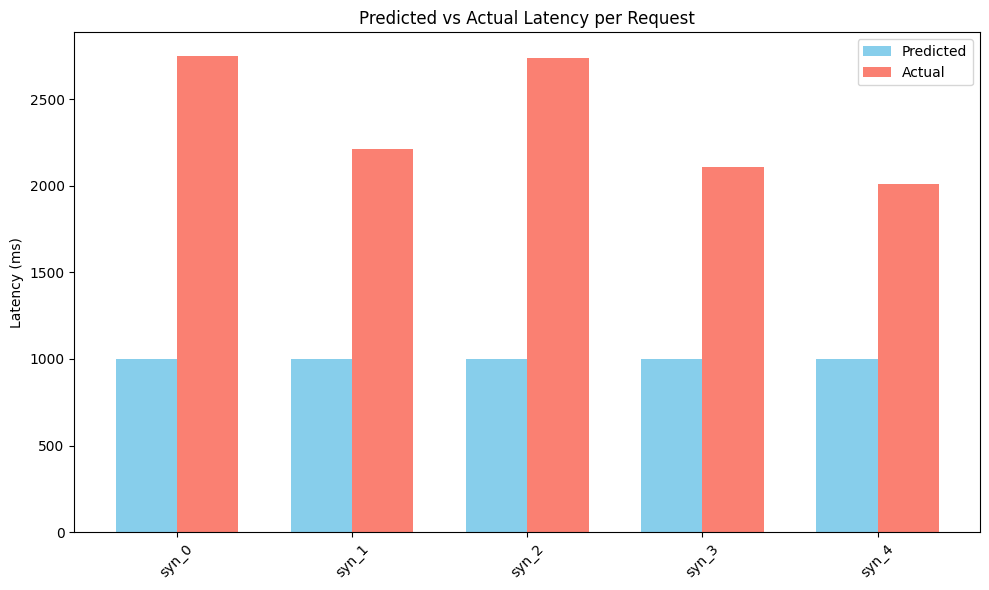


 Mean Prediction Error: 1363ms
️ ALERT: Config `base_latency_ms` needs calibration!


In [8]:
df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
x = np.arange(len(df))
width = 0.35

plt.bar(x - width/2, df['pred_latency_ms'], width, label='Predicted', color='skyblue')
plt.bar(x + width/2, df['actual_latency_ms'], width, label='Actual', color='salmon')

plt.ylabel('Latency (ms)')
plt.title('Predicted vs Actual Latency per Request')
plt.xticks(x, df['sample_id'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

mean_err = df['error_ms'].mean()
print(f"\n Mean Prediction Error: {mean_err:.0f}ms")
if abs(mean_err) > 1000:
    print("️ ALERT: Config `base_latency_ms` needs calibration!")
else:
    print(" Latency estimates are within acceptable range.")